# Code was generated by ChatGPT

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.scale = embed_dim ** 0.5

    def forward(self, x):
        Q = self.query(x)   # (batch, seq_len, embed_dim)
        K = self.key(x)
        V = self.value(x)

        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale  # (batch, seq_len, seq_len)
        attn_weights = F.softmax(attn_scores, dim=-1)  # probabilities
        out = torch.matmul(attn_weights, V)  # weighted sum

        return out, attn_weights
        



In [3]:
# Let’s say we have 1 sentence of 5 tokens, each with a 16-dim embedding:
torch.manual_seed(0)
x = torch.randn(2, 4, 8)  # batch=8, seq_len=20, embed_dim=512
attention = SimpleAttention(8)


out, attn_weights = attention(x)
print(attn_weights.shape)  # attention weight: (n, n) in a batch of h(h=8)

# Now you’ve got an attention matrix → each row says “how much this token attends to the others.”

print(attn_weights)

torch.Size([2, 4, 4])
tensor([[[0.2135, 0.2450, 0.2337, 0.3078],
         [0.1740, 0.3016, 0.1776, 0.3468],
         [0.1845, 0.3328, 0.1932, 0.2895],
         [0.1919, 0.2539, 0.2247, 0.3294]],

        [[0.2564, 0.1931, 0.2385, 0.3120],
         [0.3528, 0.3110, 0.2337, 0.1025],
         [0.1971, 0.1826, 0.2641, 0.3563],
         [0.1004, 0.2000, 0.1394, 0.5602]]], grad_fn=<SoftmaxBackward0>)


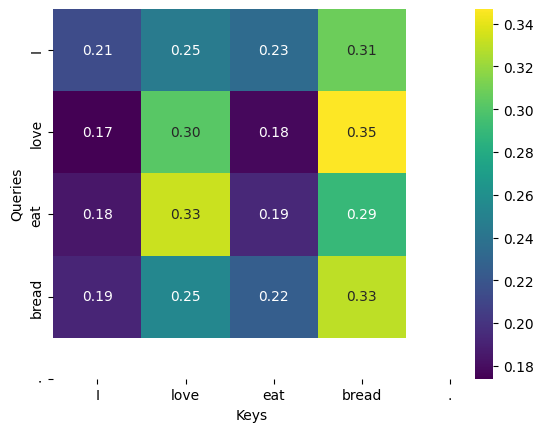

In [4]:
# Visualize attentions
import matplotlib.pyplot as plt
import seaborn as sns

tokens = ["I", "love", "eat", "bread", "."]


sns.heatmap(attn_weights[0].detach().numpy(),
            xticklabels=tokens, yticklabels=tokens,
            cmap="viridis", annot=True, fmt=".2f")

plt.xlabel("Keys")
plt.ylabel("Queries")
plt.show()
